# Endogenous Investment via Capital *and* Labour â€” a Normalised-CES Core

This notebook consolidates the project's measured results: the **normalised-CES**
core (`sigma` = elasticity of substitution between capital and labour) with an
**endogenous labour market**, a **wage curve**, **adaptive expectations**, a
**balanced-budget government**, **firm heterogeneity**, and a **global sensitivity
analysis** â€” briefs 04 through 14.

**How to read the numbers here.** Two small live sweeps (3 seeds) are run below
just to draw the picture. Everything else reads the **committed artifacts** in
`results/`, each produced by a committed driver script under `scripts/`. That is
deliberate: those runs total roughly eight hours of compute, and re-deriving them
here would risk printing numbers that disagree with the README and the paper.
The provenance of every table is stated in its section.

**The primary claim comes first.** Section 1 establishes that the response
`Y(rho)` is **U-shaped**, and that the quantity worth reporting is the location
of the turn `rho*` together with the side of it on which the empirically anchored
retention rate falls. The familiar "wage-led / profit-led" labels appear from
section 3 onward, and only as **local descriptions of one side of that turn under
a declared estimator** â€” never as a verdict on the economy.

In [1]:
import os, sys, warnings

# mesa 3.5 warns on every model construction that `seed=` is deprecated in favour of
# `rng=`. It is not a functional change and the live sweeps below would emit it hundreds
# of times, burying the output. Silenced here, deliberately and narrowly.
warnings.filterwarnings("ignore", category=FutureWarning, module="mesa")

# Locate the repo root whether the kernel starts here or in notebooks/.
here = os.getcwd()
REPO = here if os.path.isdir(os.path.join(here, "src")) else os.path.abspath(os.path.join(here, ".."))
sys.path.insert(0, os.path.join(REPO, "src"))
RESULTS = os.path.join(REPO, "results")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from experiment import (
    run_experiment, sigma_rho_sweep, sweep_derivatives, sign_frontier,
    plot_sign_frontier, cells_from_panel, common_viable_support,
    ols_slope, quadratic_curvature,
)

STEPS, SEEDS, TAIL = 2000, 3, 50
pd.set_option("display.width", 110)

# Read a committed artifact by stem, e.g. load("ces_b14_summary").
def load(name):
    return pd.read_csv(os.path.join(RESULTS, name + ".csv"))

print("repo root:", REPO)
print("committed artifacts:", len([f for f in os.listdir(RESULTS) if f.endswith(".csv")]), "CSV files")

C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: C:\Users\recursivechaos\Documents\ABM
committed artifacts: 85 CSV files


## 1. The shape of the response: `Y(rho)` is a U, and `rho*` is what matters

Everything downstream depends on one fact that a single slope hides: **steady-state
output is not monotone in the retention ratio.** It falls, turns, and rises. Brief 05
fitted a quadratic to `Y(rho)` in every `(c0, sigma)` cell and found the turning point
**inside the swept support in 19 of 22 cells**, with `|t|` up to 20.5.

That makes "the slope of `Y` on `rho`" an ill-posed summary: its sign depends on which
interval you take it over. The three quantities that *are* well posed are the ones
plotted and tabulated below â€” the whole-support OLS slope, the turning point `rho*`,
and the **side of `rho*` on which the empirically anchored range of `rho` falls**.

*Source: `results/ces_b05_stage_a_panel.csv` (20 seeds), reduced here; `rho*` and the
slopes from `results/ces_b14_taskB_slopes.csv` (`scripts/run_brief14.py --phase bridge`).*

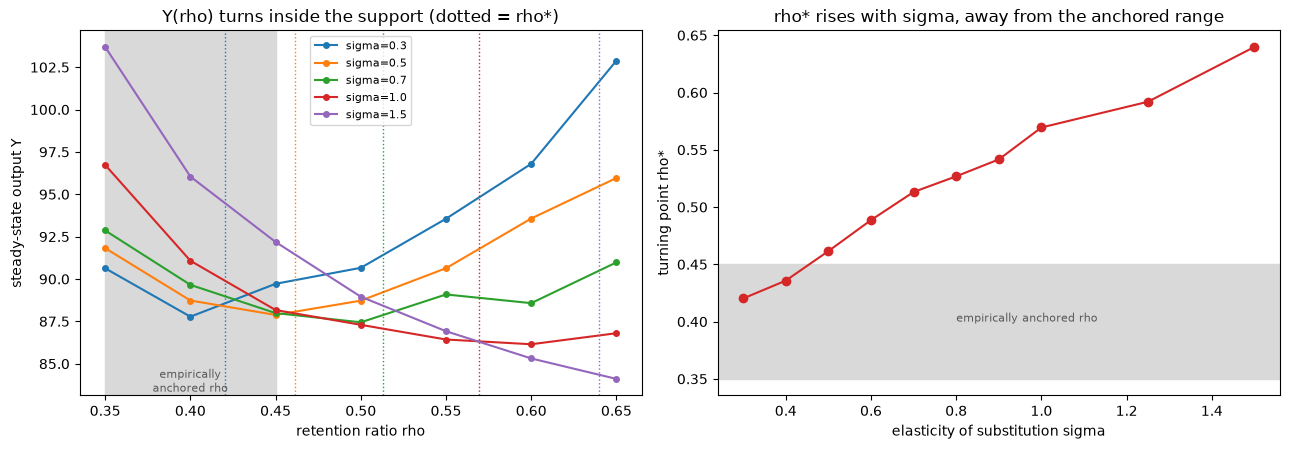

 sigma  ols_slope   chord  rho_star  rho_star_in_support empirical_rho_side
  0.05    169.737 229.311     0.674                False          undefined
  0.30     41.888  14.622     0.420                 True          straddles
  0.40     26.760   5.174     0.436                 True          straddles
  0.50     17.751  -5.929     0.462                 True               left
  0.60      5.623 -20.679     0.489                 True               left
  0.70     -4.788 -18.873     0.513                 True               left
  0.80    -11.660 -33.321     0.527                 True               left
  0.90    -19.792 -41.904     0.542                 True               left
  1.00    -29.562 -51.510     0.569                 True               left
  1.25    -45.264 -68.758     0.592                 True               left
  1.50    -61.070 -83.878     0.640                 True               left


In [2]:
panel = load("ces_b05_stage_a_panel")
panel = panel[panel["c0"] == 1.0]
keep = ["sigma", "rho", "seed"] + [c for c in panel.columns
                                   if c not in ("sigma", "rho", "seed", "c0", "eta")]
cells = cells_from_panel(panel[keep])

tb = load("ces_b14_taskB_slopes")
tb = tb[tb["scenario"] == "b05_eta=0"]

show = [0.30, 0.50, 0.70, 1.00, 1.50]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

for s in show:
    b = cells[cells["sigma"] == s].sort_values("rho")
    ax[0].plot(b["rho"], b["Y"], "o-", ms=4, label=f"sigma={s}")
    r = tb[tb["sigma"] == s]
    if len(r) and bool(r["rho_star_in_support"].iloc[0]):
        rs = float(r["rho_star"].iloc[0])
        ax[0].axvline(rs, ls=":", lw=1, color=ax[0].lines[-1].get_color())
ax[0].axvspan(0.35, 0.45, color="0.85", zorder=0)
ax[0].annotate("empirically\nanchored rho", (0.40, ax[0].get_ylim()[0]),
               ha="center", va="bottom", fontsize=8, color="0.35")
ax[0].set(xlabel="retention ratio rho", ylabel="steady-state output Y",
          title="Y(rho) turns inside the support (dotted = rho*)")
ax[0].legend(fontsize=8)

inside = tb[tb["rho_star_in_support"].astype(bool)]
ax[1].plot(inside["sigma"], inside["rho_star"], "o-", color="C3")
ax[1].axhspan(0.35, 0.45, color="0.85", zorder=0)
ax[1].annotate("empirically anchored rho", (0.8, 0.40), fontsize=8, color="0.35")
ax[1].set(xlabel="elasticity of substitution sigma", ylabel="turning point rho*",
          title="rho* rises with sigma, away from the anchored range")

fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "ces_nb_u_curve.png"), dpi=150)
plt.show()

print(tb[["sigma", "ols_slope", "chord", "rho_star",
          "rho_star_in_support", "empirical_rho_side"]].round(3).to_string(index=False))

Read the last column. **For every `sigma >= 0.5` the empirically anchored retention
rate lies to the *left* of the turn** â€” on the falling branch â€” so locally, more
retention *depresses* output, even at elasticities where the whole-support slope is
positive. The defensible statement about this model is therefore:

> *Retention depresses output while `rho` remains below a `sigma`-dependent threshold
> `rho*`, and expands it beyond; `rho*` rises with `sigma`, from 0.46 at `sigma = 0.5`
> to 0.64 at `sigma = 1.5`; and the empirically anchored retention rate lies below
> `rho*` for every `sigma` at or above 0.5.*

This does not depend on which interval an analyst picks â€” which is exactly the property
the project's original quantity of interest lacked (section 9).

**Convention from here on.** "Wage-led" means `dY/drho < 0` and "profit-led" means
`dY/drho > 0`, **under the whole-support OLS slope at the stated `(sigma, c0, eta)`**.
They are shorthand for one side of the turn, not a global claim.

## 2. The `sigma = 1` case (Cobb-Douglas)

The project's original headline, and one point on the curve above. At `sigma = 1` the
anchored range sits well left of `rho* = 0.57`, so retention depresses output across the
swept range: capital is built (256 -> 453) but it *displaces workers*, and because workers
consume more than capitalists, output falls.

*Live 3-seed sweep â€” illustrative. The 20-seed version is `ces_b05_stage_a_panel.csv`.*

 rho      Y     U  wage_share       K
0.35 95.278 0.413       0.554 251.736
0.40 90.623 0.485       0.511 281.194
0.45 88.651 0.527       0.481 311.521
0.50 87.847 0.561       0.450 351.586
0.55 86.928 0.587       0.428 385.451
0.60 88.519 0.593       0.413 420.894
0.65 84.918 0.627       0.395 441.679


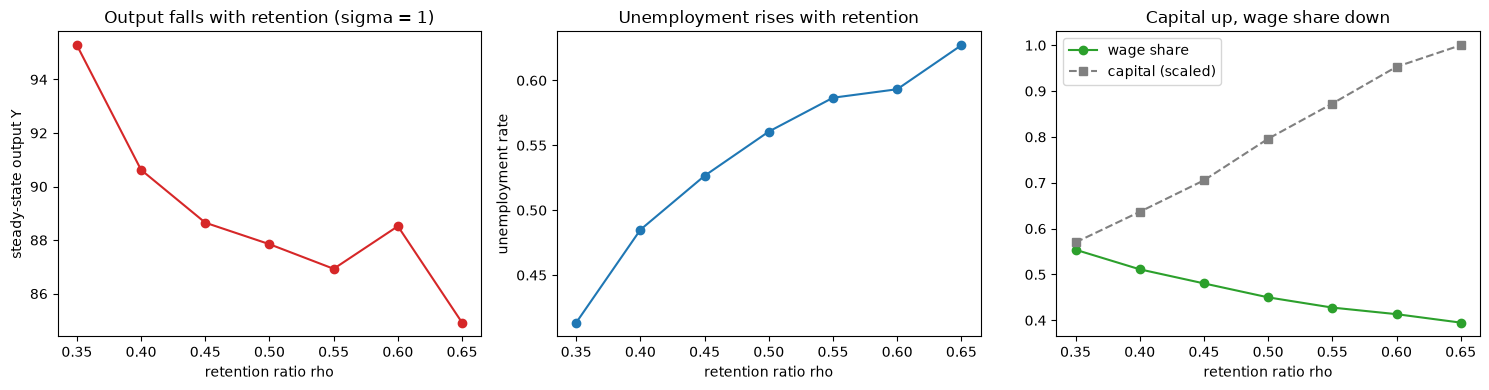

In [3]:
rhos = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
rows = []
for rho in rhos:
    p = run_experiment(rho, steps=STEPS, seeds=SEEDS, sigma=1.0, c0=1.0)
    s = p[p.index >= STEPS - TAIL].drop(columns="Seed").mean()
    rows.append(dict(rho=rho, Y=s["Output"], U=s["Unemployment_Rate"],
                     wage_share=s["Wage_Share"], K=s["Total_Capital"]))
sweep1 = pd.DataFrame(rows)
print(sweep1.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(sweep1["rho"], sweep1["Y"], "o-", color="C3")
ax[0].set(xlabel="retention ratio rho", ylabel="steady-state output Y",
          title="Output falls with retention (sigma = 1)")
ax[1].plot(sweep1["rho"], sweep1["U"], "o-", color="C0")
ax[1].set(xlabel="retention ratio rho", ylabel="unemployment rate",
          title="Unemployment rises with retention")
ax[2].plot(sweep1["rho"], sweep1["wage_share"], "o-", color="C2", label="wage share")
ax[2].plot(sweep1["rho"], sweep1["K"] / sweep1["K"].max(), "s--", color="0.5",
           label="capital (scaled)")
ax[2].set(xlabel="retention ratio rho", title="Capital up, wage share down")
ax[2].legend()
fig.tight_layout()
fig.savefig(os.path.join(REPO, "retention_sweep.png"), dpi=150)
plt.show()

## 3. The sign frontier â€” a local summary of the U

Summarising the U by a single whole-support slope and asking where that slope changes
sign gives `sigma*`. It is a useful reduction, and the project's most-quoted number, but
section 1 is why it must be read as a reduction.

`sigma* = 0.654` [0.616, 0.691] at `c0 = 1.0` (20 seeds, percentile bootstrap over
2000 resamples of the seeds). **The empirical range `sigma` 0.40-0.60 sits *below*
`sigma*`, where `dY/drho > 0`** â€” so in the empirically supported region the model is
*not* wage-led on output. The wage-led headline rests on `sigma = 1`, which the
literature rejects.

*Live 3-seed grid for the picture; the quoted `sigma*` and CI are the committed 20-seed
values in `ces_b05_sigma_star.csv`.*

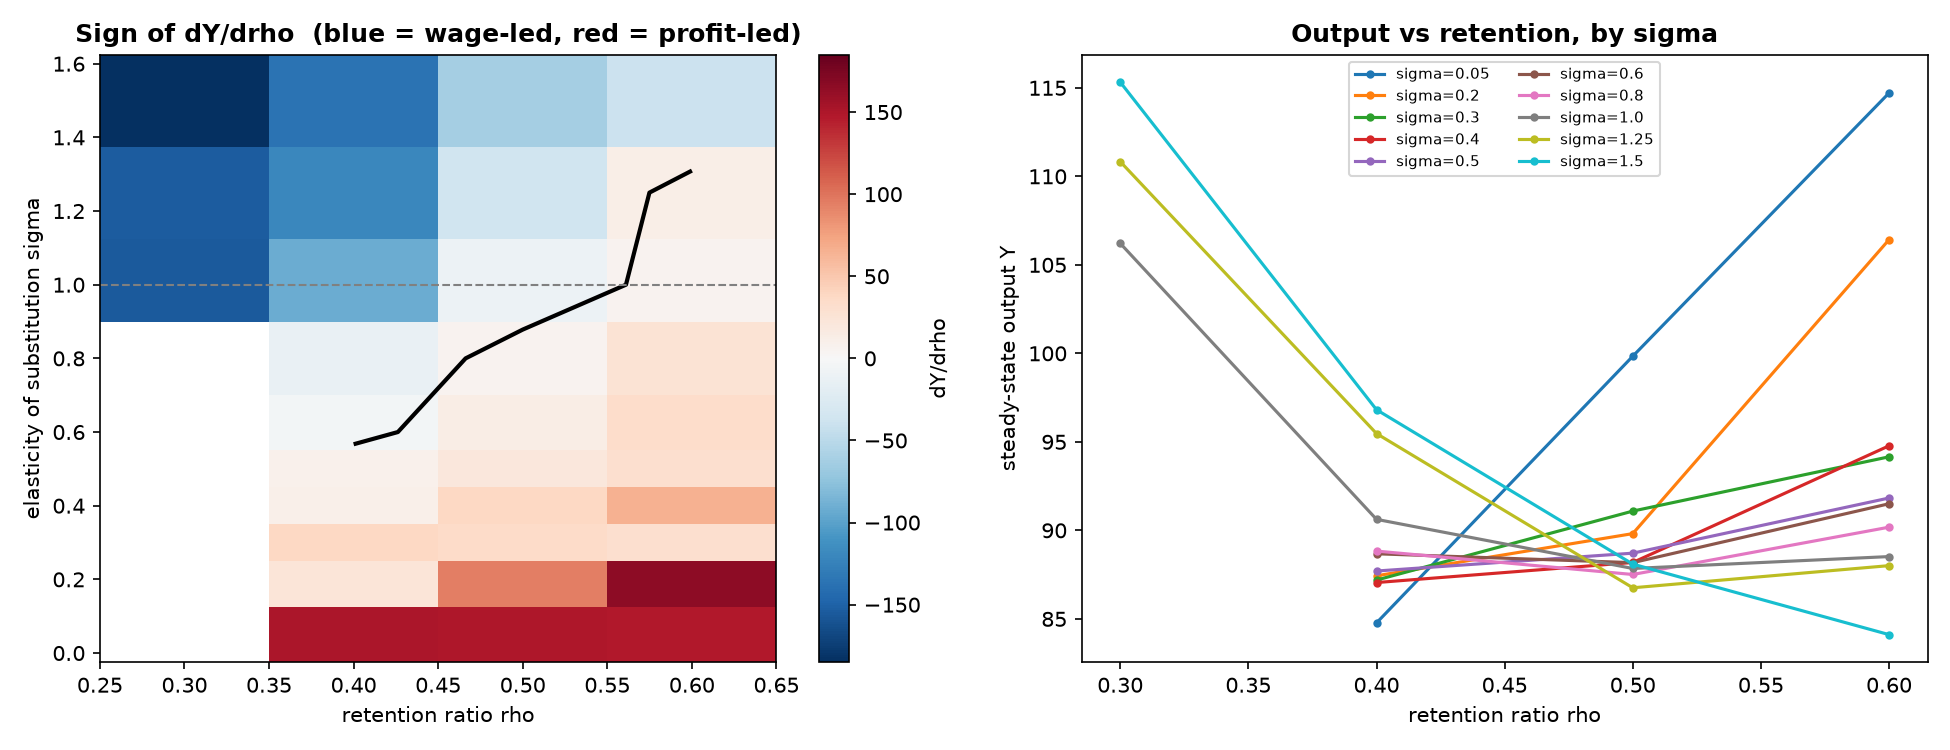

committed 20-seed sigma* (ces_b05_sigma_star.csv):
 c0    estimator  sigma_star  ci_lo  ci_hi  frac_undefined
1.0   ols_global      0.6540 0.6164 0.6908             0.0
1.0 ols_global_U      0.3141 0.2997 0.3250             0.0
2.0   ols_global      0.9415 0.9185 0.9634             0.0
2.0 ols_global_U      0.4497 0.4437 0.4561             0.0

curvature: turning point inside the support in 19 of 22 cells


In [4]:
grid = sigma_rho_sweep(steps=STEPS, seeds=SEEDS, c0=1.0)
deriv = sweep_derivatives(grid, viable_only=True)
# plot_sign_frontier draws on the Agg backend and closes the figure, so the file is the
# artifact; display it rather than calling plt.show() on a figure that no longer exists.
fig_path = plot_sign_frontier(grid, deriv, path=os.path.join(REPO, "ces_sign_frontier.png"))
display(Image(filename=fig_path))

print("committed 20-seed sigma* (ces_b05_sigma_star.csv):")
print(load("ces_b05_sigma_star")[["c0", "estimator", "sigma_star", "ci_lo", "ci_hi",
                                  "frac_undefined"]].round(4).to_string(index=False))
print("\ncurvature: turning point inside the support in",
      int(load("ces_b05_curvature")["turn_in_support"].sum()), "of",
      len(load("ces_b05_curvature")), "cells")

## 4. Wage curve (brief 07): `sigma*(eta)`

A critic can attribute the result to the *fixed* wage, which suppresses an offsetting
channel: unemployment should depress the wage, make labour cheaper, and slow substitution
toward capital. Turning that channel on does **not** rescue a wage-led reading of the
empirical band â€” it does the opposite.

`sigma*` **rises** with `eta` (0.654 -> 0.740), pushing the empirical band *deeper* into
the profit-led region, while mean unemployment *rises* (0.53 -> 0.58): the Kaleckian
paradox of costs dominates substitution. The `sigma = 1` wage-led result survives, since
`sigma = 1` stays above `sigma*` at every `eta`.

*Source: `ces_b07_sigma_star.csv`, `ces_b07_wage_u_summary.csv` (`scripts/run_brief07.py`).*

 eta  sigma_star  ci_lo  ci_hi  frac_undefined  n_crossings  U_mean
0.00      0.6540 0.6164 0.6908             0.0            1  0.5277
0.05      0.6662 0.6341 0.6918             0.0            1  0.5433
0.10      0.7246 0.6973 0.7449             0.0            2  0.5655
0.15      0.7404 0.6818 0.7931             0.0            2  0.5788


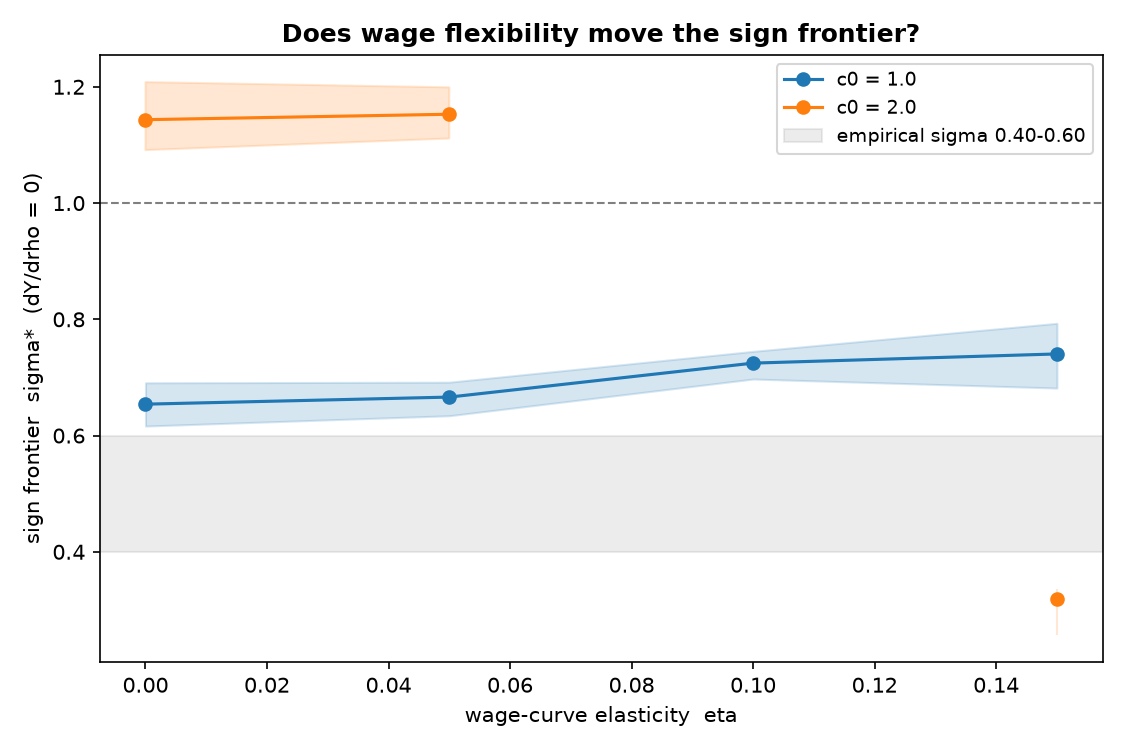

In [5]:
b07 = load("ces_b07_sigma_star")
b07 = b07[(b07["c0"] == 1.0) & (b07["target"] == "Y") & (b07["support_kind"] == "across_eta")]
wu = load("ces_b07_wage_u_summary")
wu = wu[wu["c0"] == 1.0]
tab = b07[["eta", "sigma_star", "ci_lo", "ci_hi", "frac_undefined", "n_crossings"]].merge(
    wu[["eta", "U_mean"]], on="eta")
print(tab.round(4).to_string(index=False))

display(Image(filename=os.path.join(RESULTS, "ces_b07_sigma_star_eta.png")))

## 5. Adaptive expectations (brief 08): the frontier is `lambda_e`-invariant

Hypothesis: slower demand expectations damp the `c0 = 2.0` collapse. **Falsified.**

`sigma*(eta; lambda_e)` is invariant within confidence intervals â€” every point lies inside
its neighbours' intervals. The empirical band stays below `sigma*` at every gain (profit-led
at every gain) and `sigma = 1` stays above it (wage-led at every gain): what is robust to
the expectation gain is the *location of the frontier*, and with it both readings either
side. The collapse region is `lambda_e`-invariant within grid/seed noise, and the reference
collapsing cell dies at every gain.

*Source: `ces_b08_sigma_star.csv`, `ces_b08_collapse_map.csv` (`scripts/run_brief08.py`).*

sigma*(eta; lambda_e), c0 = 1.0:
lambda_e   0.25   0.50   1.00
eta                          
0.0       0.674  0.686  0.654
0.1       0.721  0.713  0.725

fully collapsed cells at c0 = 2.0, by (eta, lambda_e):
lambda_e  0.25  0.50  1.00
eta                       
0.10         6     6     6
0.15         5     5     3


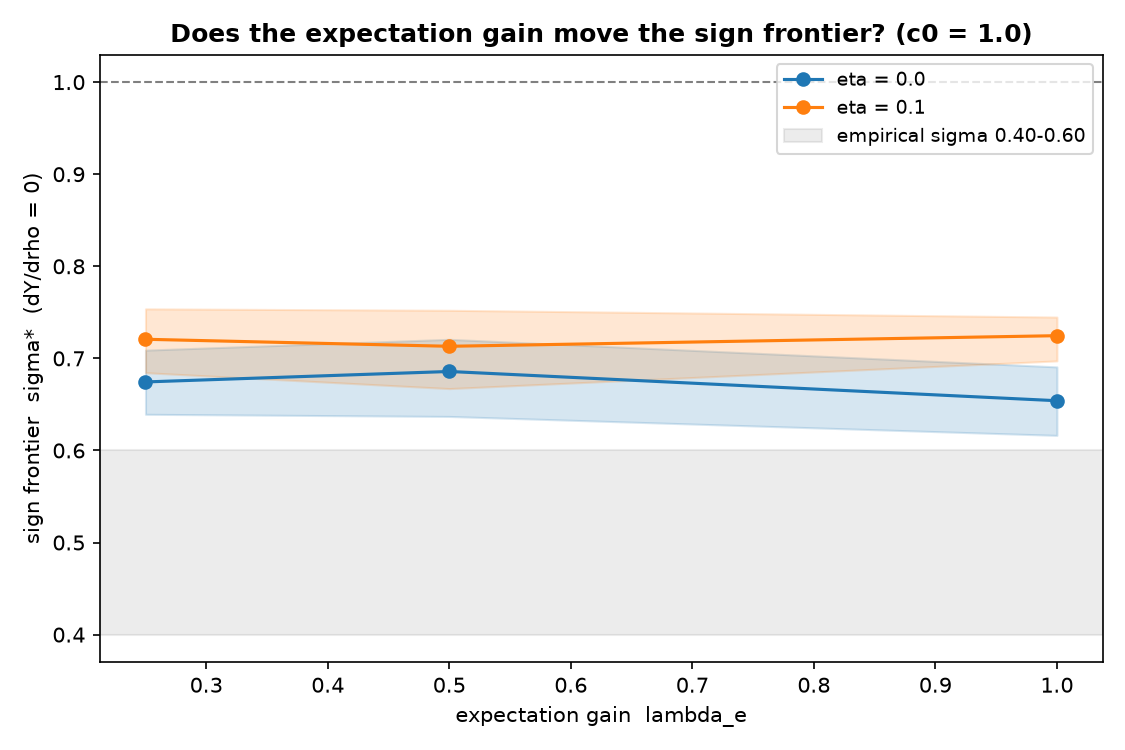

In [6]:
b08 = load("ces_b08_sigma_star")
b08 = b08[(b08["c0"] == 1.0) & (b08["target"] == "Y")]
print("sigma*(eta; lambda_e), c0 = 1.0:")
print(b08.pivot_table(index="eta", columns="lambda_e", values="sigma_star").round(3).to_string())

cm = load("ces_b08_collapse_map")
cm = cm[cm["c0"] == 2.0]
full = cm[cm["frac_seeds_collapsed"] == 1.0].groupby(["eta", "lambda_e"]).size()
print("\nfully collapsed cells at c0 = 2.0, by (eta, lambda_e):")
print(full.unstack(fill_value=0).to_string())

display(Image(filename=os.path.join(RESULTS, "ces_b08_sigma_star_lambda.png")))

## 6. Government (brief 09): a benefit crowds capital *in*, but does not stabilise

A balanced-budget unemployment benefit (flat income tax funding an equal transfer to the
unemployed), `rr = 0` nested exactly.

* **E1, dose-response.** In the demand-constrained headline scenario the benefit is
  expansionary: `U` down, `Y` up, `K` up â€” crowding *in*, not out.
* **E2, the frontier.** At `rr = 0.5` the benefit pushes `sigma*` above the whole tested
  range, i.e. it **eliminates the wage-led region**: retention becomes expansionary at
  every elasticity, by closing the leak through which the unemployed drain the circular flow.
* **E3, the stabilisation hypothesis. Falsified** â€” the collapse region does not shrink;
  with the fiscal instrument saturated at its cap it *enlarges*.

*Source: `ces_b09_dose_response.csv`, `ces_b09_sigma_star.csv`, `ces_b09_collapse_map.csv`.*

E1 dose-response:
scenario   rr  Unemployment_Rate  Output  Total_Capital  Wage_Share  Tax_Rate
  anchor 0.00              0.257 132.090        418.409       0.506     0.000
  anchor 0.25              0.221 138.757        440.595       0.505     0.043
  anchor 0.50              0.197 143.116        454.597       0.505     0.074
  anchor 0.75              0.177 146.962        468.754       0.504     0.097
headline 0.00              0.566  82.083        298.747       0.440     0.000
headline 0.25              0.483  98.125        359.213       0.446     0.128
headline 0.50              0.427 108.701        396.595       0.452     0.206
headline 0.75              0.373 119.005        435.714       0.457     0.250

E2 sigma*(eta; rr) on Y:
 c0  eta  rr  sigma_star  ci_lo  ci_hi  frac_undefined
1.0  0.0 0.0       0.830  0.766  0.866           0.000
1.0  0.0 0.0       0.654  0.616  0.691           0.000
1.0  0.0 0.5         NaN    NaN    NaN           1.000
1.0  0.1 0.0       0.833  0.790  0

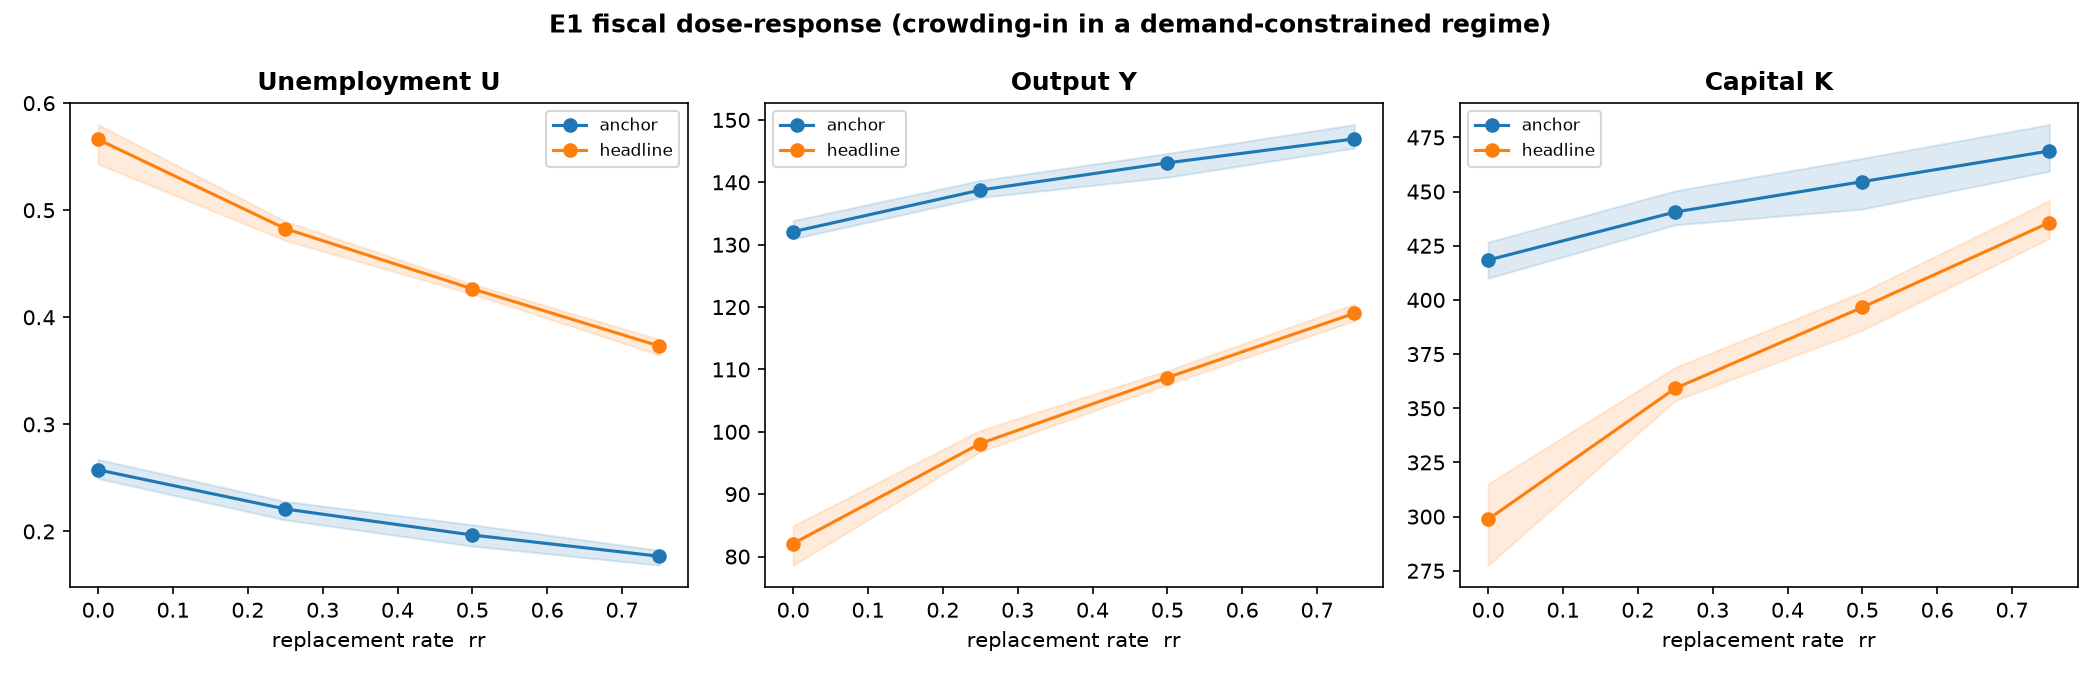

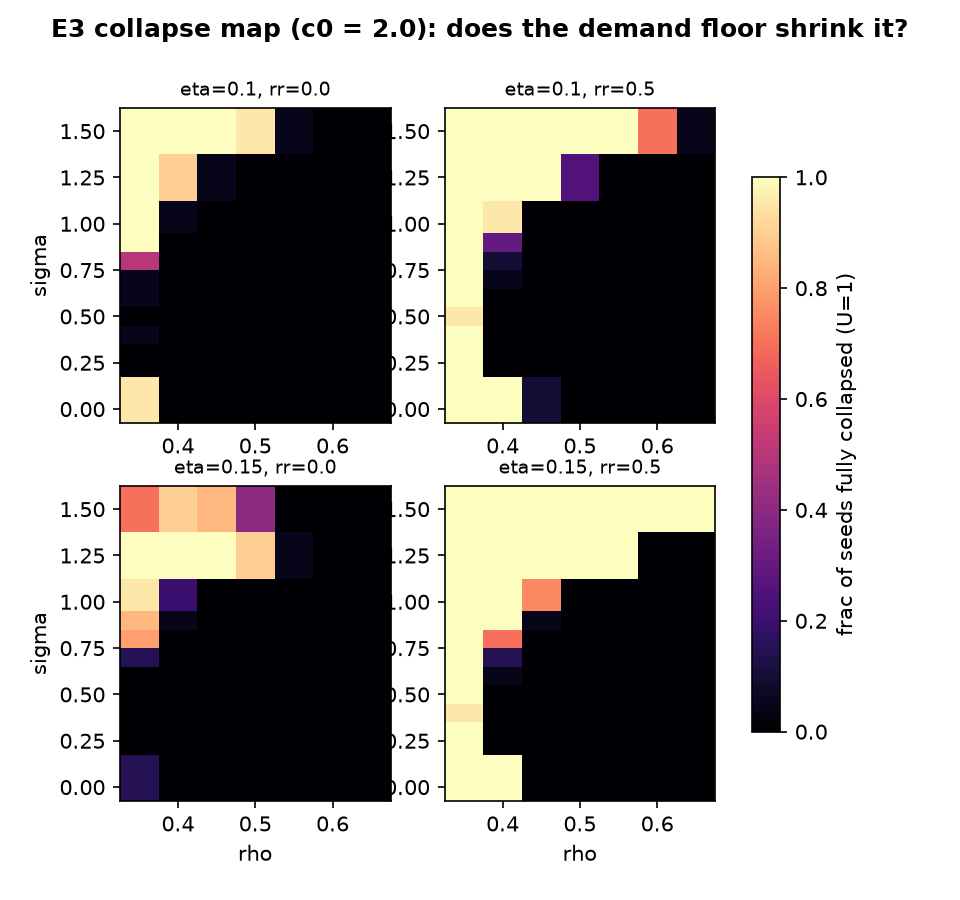

In [7]:
dose = load("ces_b09_dose_response")
cols = ["scenario", "rr", "Unemployment_Rate", "Output", "Total_Capital", "Wage_Share", "Tax_Rate"]
print("E1 dose-response:")
print(dose[cols].round(3).to_string(index=False))

b09 = load("ces_b09_sigma_star")
print("\nE2 sigma*(eta; rr) on Y:")
print(b09[b09["target"] == "Y"][["c0", "eta", "rr", "sigma_star", "ci_lo", "ci_hi",
                                 "frac_undefined"]].round(3).to_string(index=False))

cm9 = load("ces_b09_collapse_map")
e3 = cm9[cm9["c0"] == 2.0].groupby(["eta", "rr"])["frac_seeds_collapsed"].apply(
    lambda s: (s > 0).sum())
print("\nE3: cells with any collapse at c0 = 2.0, by (eta, rr):")
print(e3.unstack(fill_value=0).to_string())

for f in ("ces_b09_dose_response.png", "ces_b09_collapse_map.png"):
    display(Image(filename=os.path.join(RESULTS, f)))

## 7. Firm heterogeneity (brief 10): a cliff, and a domino

Why the firms are homogeneous â€” a structural assumption, tested. With `A_i` dispersed
mean-preservingly and **no reallocation channel** (no selection, no demand rerouting, no
entry/exit), there is a dispersion threshold: below it the aggregates are indistinguishable
from the homogeneous model; above it the economy collapses through a **domino**. The
low-`A` firm serves the same network demand with more labour, so profit falls,
`I < delta*K`, and its capital goes to zero; spending shares stay pointed at the dead firm
and its laid-off workers lose their income, so the high-`A` firms die too.

The brief-09 benefit does **not** cushion it â€” it *lowers* the threshold (the third
falsified stabilisation hypothesis).

*Source: `ces_b10_thresholds.csv`, `ces_b10_summary.csv` (`scripts/run_brief10.py`).*

viability thresholds by scenario:
   scenario  spread_first_death  spread_full_collapse  threshold_frac
  S1_anchor               0.125                 0.125             0.5
S2_headline               0.150                 0.150             0.5
 S3_benefit               0.125                 0.150             0.5

aggregates vs dispersion:
   scenario  spread  Unemployment_Rate  Output  Total_Capital  Dead_Firms
  S1_anchor   0.000              0.257 132.090        418.409        0.00
  S1_anchor   0.050              0.250 133.001        420.730        0.00
  S1_anchor   0.100              0.229 134.697        421.704        0.00
  S1_anchor   0.125              1.000   0.000          0.000       10.00
  S1_anchor   0.150              1.000   0.000          0.000       10.00
  S1_anchor   0.175              1.000   0.000          0.000       10.00
  S1_anchor   0.200              1.000   0.000          0.000       10.00
S2_headline   0.000              0.566  82.083        298.747      

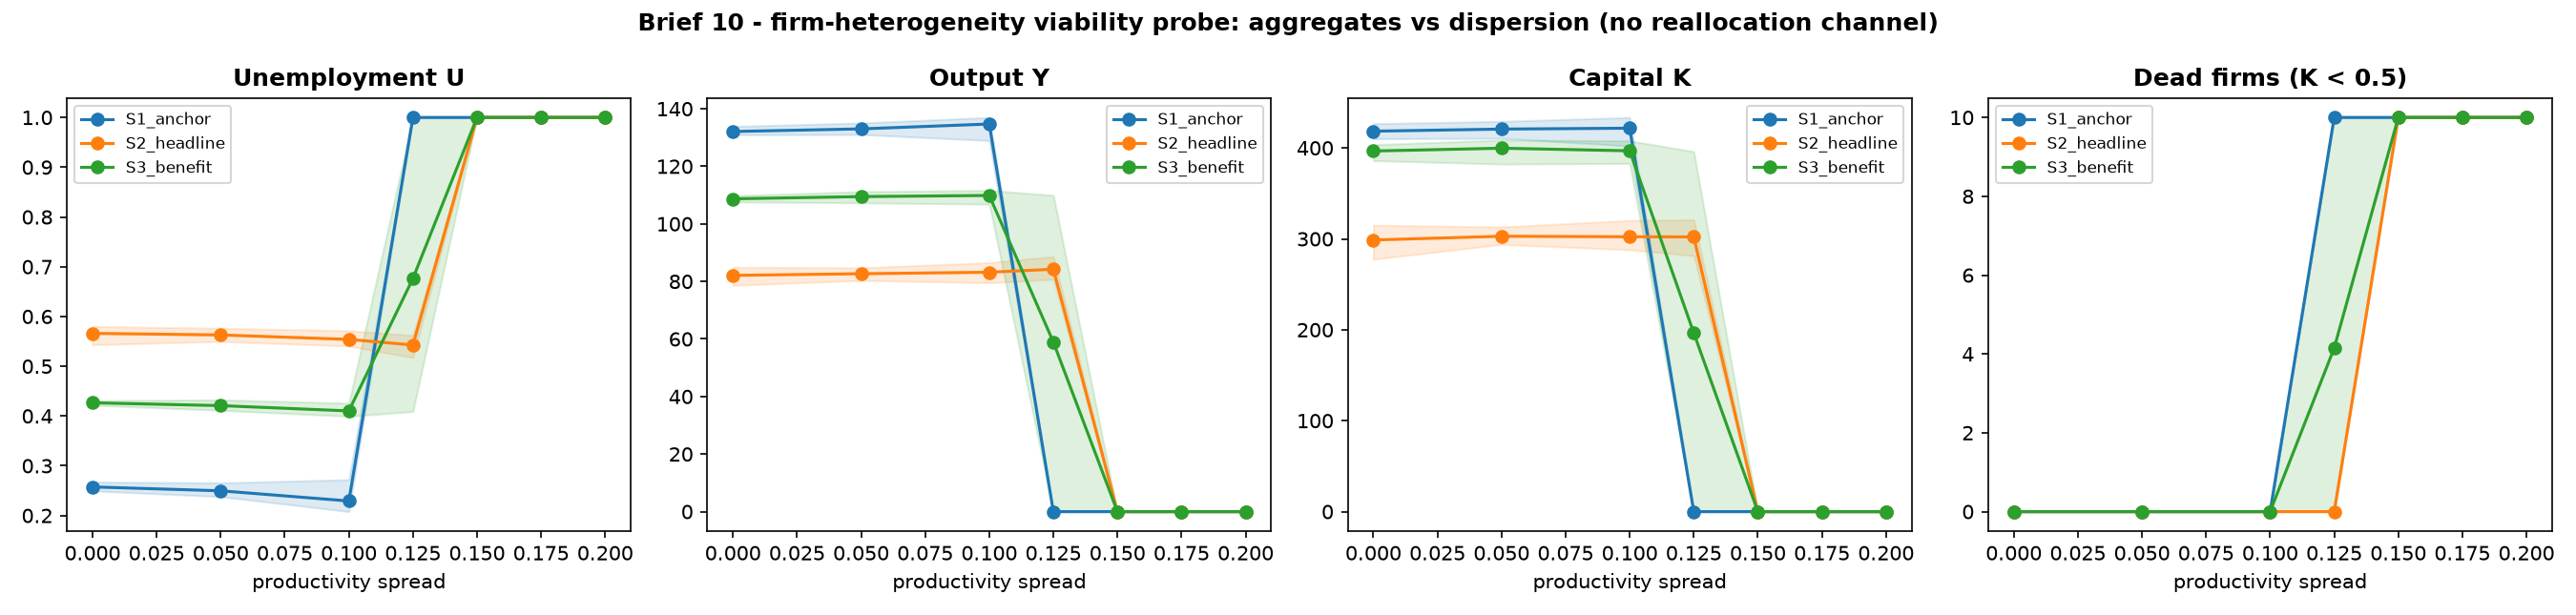

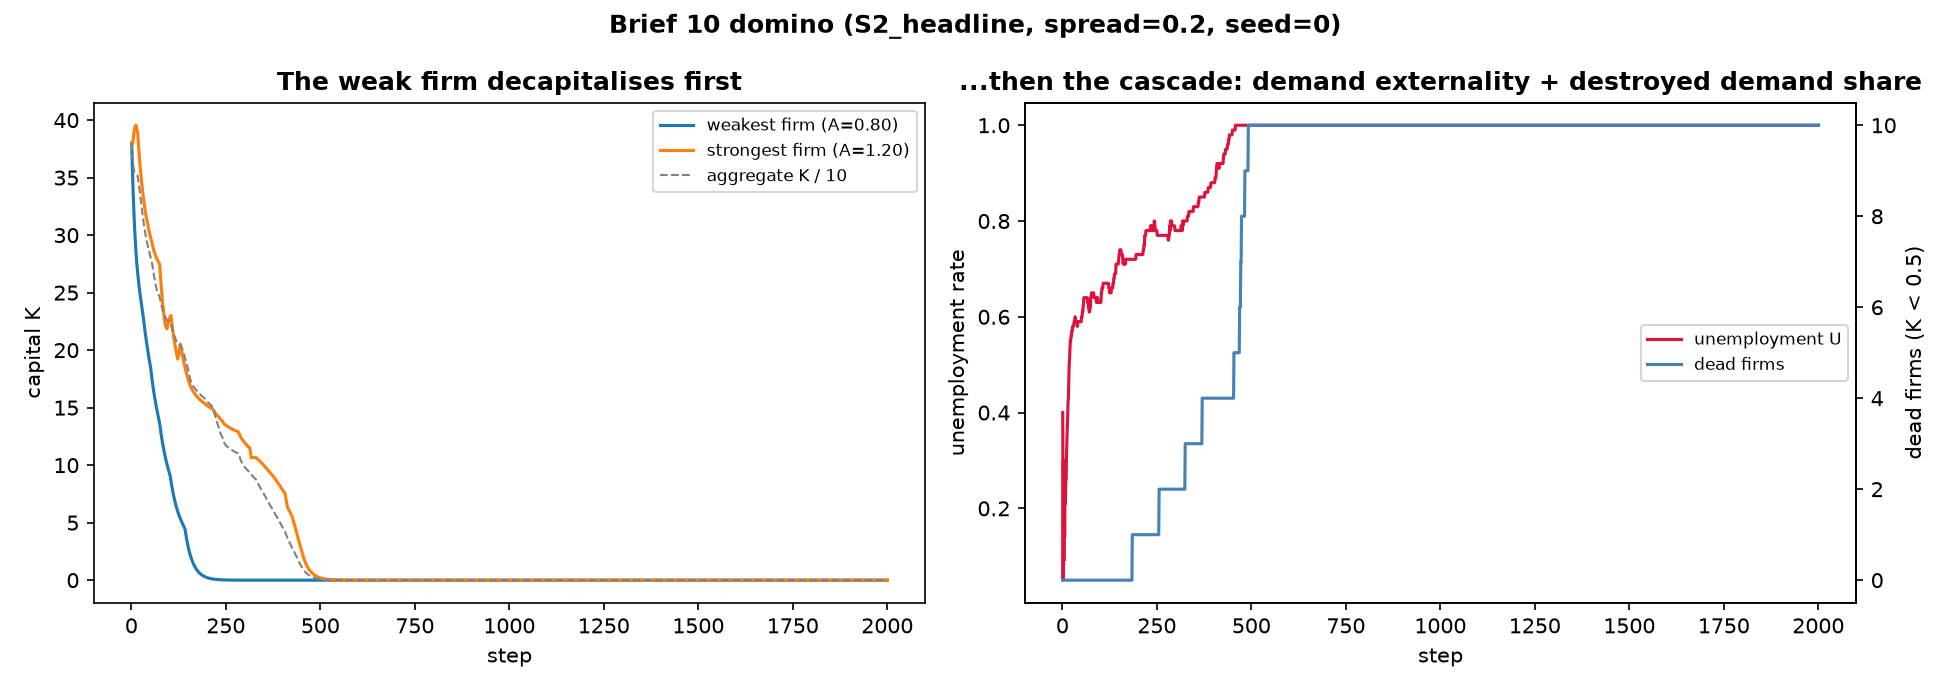

In [8]:
print("viability thresholds by scenario:")
print(load("ces_b10_thresholds")[["scenario", "spread_first_death", "spread_full_collapse",
                                  "threshold_frac"]].to_string(index=False))

s10 = load("ces_b10_summary")
print("\naggregates vs dispersion:")
print(s10[["scenario", "spread", "Unemployment_Rate", "Output", "Total_Capital",
           "Dead_Firms"]].round(3).to_string(index=False))

for f in ("ces_b10_aggregates_spread.png", "ces_b10_domino_trace.png"):
    display(Image(filename=os.path.join(RESULTS, f)))

## 8. Anchoring (brief 11), and the structural limit on `delta`

Measured ratios against their empirical comparators, and the one place where the model
provably cannot be reconciled with the data.

The accounting closure is `I/K = delta + g`. Growth in `A` is roadmap point 13 and is
**cut**, so `g = 0`: steady-state investment covers depreciation and nothing else. Two
consequences, which are the same fact seen from two sides:

1. **Levels.** The model cannot match business `I/Y` and `K/Y` jointly. Matching them
   would need `delta ~ 0.11`, i.e. roughly `delta_data + g`.
2. **Viability.** At the depreciation rate the data imply for this model's perimeter
   (BEA private non-residential, `delta ~ 0.090`), **0 of 843 sampled points survive**,
   and `delta` alone governs survival (`ST = 1.00`).

So `delta = 0.05` is not where the data put it â€” it is **where `g = 0` forces it to sit
for the model to survive at all**. A declared structural limitation, not a parameter to tune.

*Source: `ces_b11_anchoring_ratios.csv`, `ces_b13_sobol_byproducts.csv`.*

In [9]:
anc = load("ces_b11_anchoring_ratios")
print(anc[["scenario", "rho", "I_over_Y", "K_over_Y", "I_over_K"]].round(4).to_string(index=False)
      if "K_over_Y" in anc.columns else anc.round(4).to_string(index=False))

bp = load("ces_b13_sobol_byproducts")
d = bp[bp["parameter"] == "delta"][["bin_lo", "bin_hi", "n_points", "frac_viable",
                                    "n_viable", "P_wage_led_given_viable"]]
print("\nthe delta cliff (Sobol primary, N=256):")
print(d.round(3).to_string(index=False))
print("\nviable points in the empirically implied band [0.075, 0.090]:",
      int(d.iloc[-1]["n_viable"]), "of", int(d.iloc[-1]["n_points"]))

scenario  rho  I_over_Y  K_over_Y  I_over_K
  anchor 0.35    0.1348    2.6990    0.0499
  anchor 0.40    0.1583    3.1676    0.0500
  anchor 0.45    0.1806    3.6175    0.0499
  anchor 0.50    0.2040    4.0697    0.0501
  anchor 0.55    0.2261    4.5198    0.0500
  anchor 0.60    0.2480    4.9646    0.0500
  anchor 0.65    0.2698    5.3896    0.0501
headline 0.35    0.1608    3.2049    0.0502
headline 0.40    0.1823    3.6397    0.0501
headline 0.45    0.2025    4.0607    0.0499
headline 0.50    0.2229    4.4489    0.0501
headline 0.55    0.2416    4.8407    0.0499
headline 0.60    0.2613    5.1998    0.0503
headline 0.65    0.2810    5.6153    0.0501

the delta cliff (Sobol primary, N=256):
 bin_lo  bin_hi  n_points  frac_viable  n_viable  P_wage_led_given_viable
  0.030   0.045       832        0.992       825                    0.044
  0.045   0.060       832        0.758       631                    0.111
  0.060   0.075       821        0.183       150                    0.313
  0

## 9. The repaired sensitivity analysis (briefs 13-14)

Brief 13 ran a global SA whose quantity of interest was a **two-point chord** of
`Y(rho)` between 0.35 and 0.55. Section 1 is why that was the wrong instrument: on a U,
a chord's sign depends on where it is taken. Brief 14 replaced it with the **OLS slope
over four `rho` values** â€” the same estimator that defines `sigma*` â€” with parameters,
ranges and sampling seed *imported* from the brief-13 driver so the QoI is the only thing
that differs, and with both estimators computed **from the same runs**.

**The bridging experiment.** A 2x2 (chord vs OLS) x (parameters fixed vs marginalised),
under a verdict rule frozen in the source before execution. Verdict: **cause (a)** â€” the
estimator. The two give non-overlapping intervals on identical data. Marginalising moves
`sigma*` even further (0.643 -> 0.962), but *away* from the empirical band rather than
across it, so the rule does not fire â€” reported anyway, because the rule not firing is
not the same as the effect being absent.

*Source: `ces_b14_bridge.csv`, `ces_b14_summary.csv`, `ces_b14_morris.csv`,
`ces_b14_sobol_indices.csv`, `ces_b14_wide_design.csv` (`scripts/run_brief14.py`).*

In [10]:
br = load("ces_b14_bridge")
g4 = br[(br["support"] == "grid4") &
        ((br["arm"] == "marginalised") | (br["scenario"] == "b07_eta=0"))]
print("the 2x2 (grid4 support, eta = 0 fixed arm):")
print(g4[["arm", "method", "sigma_star", "ci_lo", "ci_hi"]].round(3).to_string(index=False))

anchor = br[(br["scenario"] == "b05_eta=0") & (br["support"] == "canonical") &
            (br["method"] == "ols")]["sigma_star"].iloc[0]
print(f"\nanchoring control: cell 2 on the canonical support = {anchor!r}")
print("canonical published value                          = 0.6540142777288407")

the 2x2 (grid4 support, eta = 0 fixed arm):
         arm method  sigma_star  ci_lo  ci_hi
       fixed    ols       0.643  0.596  0.701
       fixed  chord       0.447  0.395  0.501
marginalised    ols       0.962  0.723  0.985
marginalised  chord       0.938  0.573  0.976

anchoring control: cell 2 on the canonical support = np.float64(0.6540142777288407)
canonical published value                          = 0.6540142777288407


### What the repair changes, and what it does not

Both estimators on the same runs. The chord column reproduces brief 13 (0.094 against
0.095; 0.202 against 0.201) â€” the residual is the changed survivor set, not the estimator.

In [11]:
s14 = load("ces_b14_summary")
print(s14[["analysis", "frac_viable_4rho", "P_wage_led_chord_given_viable",
           "P_wage_led_OLS_given_viable"]].round(3).to_string(index=False))

new = load("ces_b14_sobol_indices"); old = load("ces_b13_sobol_indices")
for q in ("slope_raw", "viable"):
    a = new[(new["qoi"] == q) & (new["estimator"] == "saltelli")][["parameter", "S1", "S1_conf", "ST", "ST_conf"]]
    b = old[(old["qoi"] == q) & (old["estimator"] == "saltelli")][["parameter", "ST"]].rename(
        columns={"ST": "ST_brief13"})
    m = a.merge(b, on="parameter", how="left").sort_values("ST", ascending=False)
    print(f"\nSobol indices, QoI = {q} (repaired vs brief 13):")
    print(m.head(6).round(3).to_string(index=False))

                           analysis  frac_viable_4rho  P_wage_led_chord_given_viable  P_wage_led_OLS_given_viable
primary (empirical sigma 0.40-0.60)             0.480                          0.094                        0.026
        wide sigma check (0.3, 1.0)             0.468                          0.202                        0.098

Sobol indices, QoI = slope_raw (repaired vs brief 13):
     parameter     S1  S1_conf    ST  ST_conf  ST_brief13
         delta  0.364    0.147 0.900    0.146       0.966
           pi0 -0.033    0.126 0.561    0.130       0.562
            c0  0.033    0.086 0.263    0.075       0.276
 wealth_effect -0.040    0.062 0.174    0.059       0.264
capitalist_mpc -0.024    0.053 0.125    0.044       0.187
          beta -0.014    0.039 0.068    0.036       0.052

Sobol indices, QoI = viable (repaired vs brief 13):
         parameter     S1  S1_conf    ST  ST_conf  ST_brief13
             delta  0.711    0.141 0.916    0.122       1.002
               pi0 

The headline probability moves by a factor of 3.6; the **variance decomposition barely
moves at all**. *Which* parameters generate the variance is robust to the estimator; the
*level* of the wage-led probability is not. Those are different questions, and brief 13's
answer to the first stands.

The difference is not diffuse either â€” it is 108 individually identifiable design points,
and what distinguishes them is exactly the mechanism of section 1.

In [12]:
q = load("ces_b14_sobol_qoi"); v = q[q["viable"] == 1.0]
dis = v[np.sign(v["chord"]) != np.sign(v["slope"])]
co = int(((dis["chord"] < 0) & (dis["slope"] > 0)).sum())
oc = int(((dis["slope"] < 0) & (dis["chord"] > 0)).sum())
print(f"viable points                       {len(v)}")
print(f"sign disagreements chord vs OLS     {len(dis)}  ({co} chord<0<OLS, {oc} the reverse)")
print(f"net                                 {co - oc}")
print(f"headline gap in points              "
      f"{int((v['chord'] < 0).sum() - (v['slope'] < 0).sum())}")
print(f"\nmean rho* where they DISAGREE       {dis['rho_star'].mean():.3f}   (inside the chord window)")
agree = v[np.sign(v['chord']) == np.sign(v['slope'])]
print(f"mean rho* where they AGREE          {agree['rho_star'].mean():.3f}   (outside the support)")
print(f"\nrho* resolved inside the support    {v['rho_star_in_support'].mean():.3f}"
      "   <- declared limit: the U is not resolved everywhere marginally")

viable points                       1596
sign disagreements chord vs OLS     112  (110 chord<0<OLS, 2 the reverse)
net                                 108
headline gap in points              108

mean rho* where they DISAGREE       0.473   (inside the chord window)
mean rho* where they AGREE          0.820   (outside the support)

rho* resolved inside the support    0.377   <- declared limit: the U is not resolved everywhere marginally


### The wide-`sigma` check â€” the direct test

Brief 13 reported an apparent **inversion**: wage-led rare below `sigma ~ 0.65` and common
above, which it read as contradicting the sign frontier. **It does not.** Below `sigma*`
the model is profit-led, so "wage-led rare below 0.65" is the *same* direction as the
frontier, not its opposite. That was a reading error in the project's own write-up, and it
is corrected here and in the README.

Repeating the check with the repaired QoI: wage-led becomes **more** common as `sigma`
rises under *both* estimators â€” the same direction as section 3 â€” and never crosses 0.5.

In [13]:
wd = load("ces_b14_wide_design"); vw = wd[wd["viable"] == 1.0]
edges = np.linspace(wd["sigma"].min(), wd["sigma"].max(), 5)
rows = []
for lo, hi in zip(edges, edges[1:]):
    sel = vw[(vw["sigma"] >= lo) & ((vw["sigma"] <= hi) if hi == edges[-1] else (vw["sigma"] < hi))]
    rows.append({"sigma_bin": f"{lo:.3f}-{hi:.3f}", "n_viable": len(sel),
                 "P_wage_led_OLS": (sel["slope"] < 0).mean(),
                 "P_wage_led_chord": (sel["chord"] < 0).mean(),
                 "mean_OLS_slope": sel["slope"].mean()})
print(pd.DataFrame(rows).round(3).to_string(index=False))


# The survivor set is recomputed with the driver's own declared rule, not asserted.
sys.path.insert(0, os.path.join(REPO, "scripts"))
from run_brief13 import apply_keep_rule

s14 = apply_keep_rule(load("ces_b14_morris"))
s13 = apply_keep_rule(load("ces_b13_morris"))
print("\nMorris was redone, not reused - and the survivor set changed:")
print("  brief 13:", ", ".join(s13))
print("  brief 14:", ", ".join(s14))
print("  added   :", [p for p in s14 if p not in s13] or "none")
print("  dropped :", [p for p in s13 if p not in s14] or "none")
print("\n(A different survivor set is a different design matrix, which is also why the")
print(" brief-13 runs could not have been recycled even in principle.)")

  sigma_bin  n_viable  P_wage_led_OLS  P_wage_led_chord  mean_OLS_slope
0.301-0.475       191           0.000             0.016          81.756
0.475-0.649       197           0.025             0.127          55.144
0.649-0.823       201           0.154             0.299          50.477
0.823-0.998       190           0.211             0.363          35.390

Morris was redone, not reused - and the survivor set changed:
  brief 13: sigma, eta, benefit_replacement_rate, pi0, pct_capitalists, delta, c1, wealth_effect, capitalist_mpc, beta, c0
  brief 14: sigma, eta, pi0, pct_capitalists, delta, c1, wealth_effect, capitalist_mpc, beta, target_utilization, c0
  added   : ['target_utilization']
  dropped : ['benefit_replacement_rate']

(A different survivor set is a different design matrix, which is also why the
 brief-13 runs could not have been recycled even in principle.)


## 10. Reading of the results

* **The primary statement is about the turn, not a label.** `Y(rho)` is U-shaped; `rho*`
  rises with `sigma`; the empirically anchored `rho` lies left of the turn for every
  `sigma >= 0.5`. Everything else in this notebook is a reduction of that.
* **The regime is demand-constrained almost everywhere** in the viable cells; `sigma` acts
  *inside* the regime rather than switching it â€” which is why the sign is a genuine outcome
  and not an artefact of a capacity ceiling.
* **Conditionally, the sign structure is clean**: a frontier at `sigma* ~ 0.65` that rises
  with wage flexibility, is invariant to expectation dynamics, and is eliminated by a
  balanced-budget benefit. The empirical band `sigma` 0.40-0.60 sits **below** it, i.e.
  profit-led; the wage-led headline rests on `sigma = 1`.
* **Marginally, that structure largely dissolves.** Wage-led outcomes are the exception
  (0.026 with the repaired QoI), `sigma` explains ~2% of the variance, and survival is
  governed almost entirely by `delta`.
* **One channel survived everything**: wage -> unemployment -> capital erosion. It emerged
  unlooked-for from the wage curve and killed three consecutive stabilisation hypotheses.
  Demand instruments work where demand binds, and not against wage-driven capital erosion.
* **Two limits, declared.** At the empirically implied `delta` the model does not exist;
  and marginally the U's turn is resolved inside the support in only 38% of viable points,
  so the primary statement is a conditional one and is not silently promoted.
* The model has **multiple equilibria and a viability threshold near `rho ~ 0.30`**;
  `initial_capital` selects the basin and is held fixed. Collapsed cells are an outcome.